##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [ ]:
! pip install -U keras-cv keras tensorflow

In [1]:
import tensorflow as tf
import numpy as np
import keras
import keras_cv
from keras_cv import visualization

tf.config.run_functions_eagerly(True)

In [2]:
# Load the YOLOV8 Model 
print("Loading YOLOV8 model...")
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc", 
    bounding_box_format="xywh"
)

# Resizing Layer
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

Loading YOLOV8 model...



--- INFERENCE START ---


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

RESULTS FOR: dog.jpg
  - Detected: bicycle (Score: 87.76%)
  - Detected: car (Score: 82.61%)
  - Detected: dog (Score: 59.77%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

RESULTS FOR: eagle.jpg
  - Detected: bird (Score: 98.94%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

RESULTS FOR: giraffe.jpg
  - Detected: dog (Score: 97.14%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

RESULTS FOR: person.jpg
  - Detected: dog (Score: 97.59%)
  - Detected: cow (Score: 97.49%)
  - Detected: person (Score: 92.50%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

RESULTS FOR: horses.jpg
  - Detected: cow (Score: 96.11%)
  - Detected: cow (Score: 87.90%)
  - Detected: cow (Score: 80.66%)


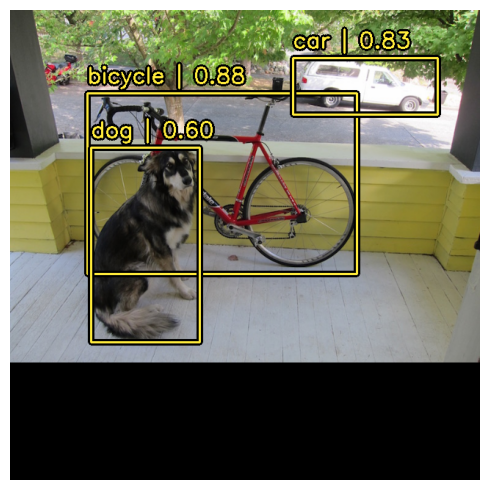

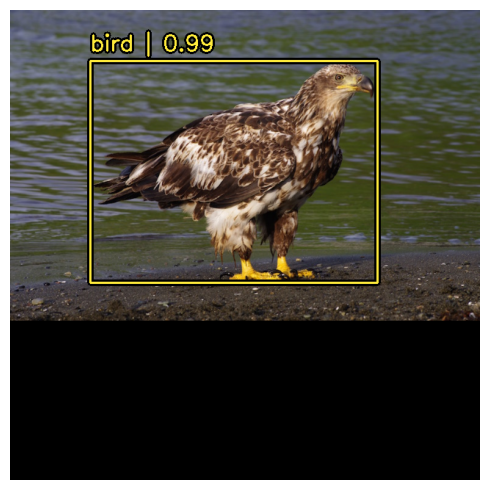

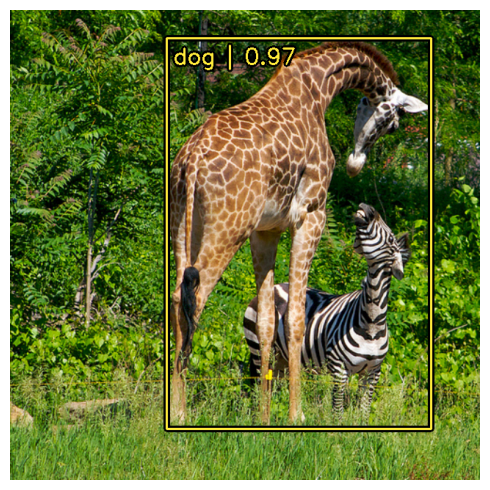

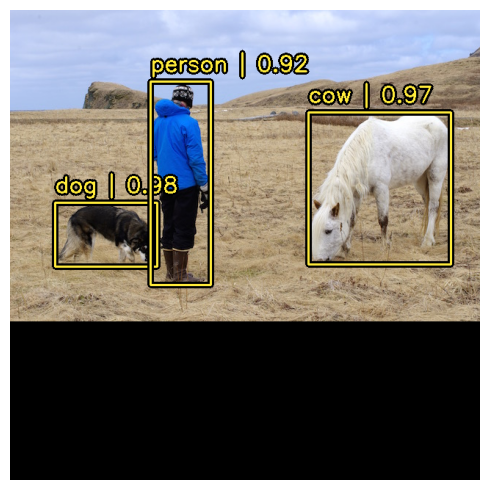

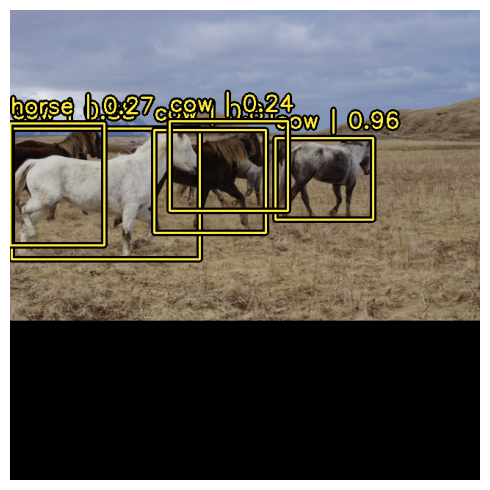

In [3]:
# Define Pascal VOC Class Mapping
class_ids = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat", 
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person", 
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
class_mapping = dict(zip(range(len(class_ids)), class_ids))

# Process Images and Run Inference
image_paths = ["dog.jpg", "eagle.jpg", "giraffe.jpg", "person.jpg", "horses.jpg"]

print("\n--- INFERENCE START ---")

for path in image_paths:
    # Load image
    img = keras.utils.load_img(path)
    img_array = keras.utils.img_to_array(img)
    
    # Resize image to 640x640
    image_batch = inference_resizing(np.expand_dims(img_array, axis=0))
    
    # Run Prediction
    y_pred = model.predict(image_batch)
    
    # Visualize 
    print(f"\nRESULTS FOR: {path}")
    
    # Extract prediction data
    confs = y_pred['confidence'][0]
    classes = y_pred['classes'][0].astype(int)
    
    found = False
    for i in range(len(confs)):
        if confs[i] > 0.3: # Confidence threshold
            label = class_mapping.get(classes[i], "Unknown")
            print(f"  - Detected: {label} (Score: {confs[i]:.2%})")
            found = True
            
    if not found:
        print("  - No objects detected above 30% confidence.")

    # Display/Save visualized result
    visualization.plot_bounding_box_gallery(
        image_batch,
        value_range=(0, 255),
        y_pred=y_pred,
        rows=1, cols=1,
        scale=5,
        class_mapping=class_mapping,
        bounding_box_format="xywh"
    )

## Record for each image

| Image | Correct Detections | Confidence Scores | Missed or Incorrectly Labeled |
| :--- | :--- | :--- | :--- |
| **1. dog.jpg** | Bicycle, Car, Dog | Bicycle: 88%, Car: 83%, Dog: 60% | None |
| **2. eagle.jpg** | Bird | Bird: 99% | None |
| **3. giraffe.jpg**| None | Dog: 97% | **Incorrect:** Giraffe labeled as "dog" |
| **4. person.jpg** | Person, Dog | Person: 92%, Dog: 98% | Horse in the background is labeled as "cow" (97%) |
| **5. horses.jpg** | Only one horse with 27% | Horse: 27%, Cow: 96%, 88%, 81%, 24% | **Incorrect:** The rest horses labeled as "cow" |